<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

Mecânica dos Sólidos I

# II. Análise de extensões. Extensometria. Equações da compatibilidade.

## Problema 2 <a name="PII52"></a>

Numa roseta de extensómetros são obtidas leituras em direções a 45 $^\circ$ como as representadas na Figura. Se $\varepsilon_a = 120 \times 10^{-6}$, $\varepsilon_b = 280 \times 10^{-6}$ e $\varepsilon_c = 700 \times 10^{-6}$. Determine a direção e a grandeza das deformações principais no plano da roseta.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au05/Au05_P002_i1.jpg"
width="300" height="280">




## Resolução

A roseta de 45$^\circ$ mede a extensão linear ao longo de três direções ao longo dos eixos dos $xx$ e $yy$ e da bissetriz do ângulo formado pelos eixos $x$ e $y$. A contribuição dos três elementos da roseta conduz ao seguinte sistema de equações:

\begin{equation*}
\begin{cases}
\varepsilon_\mathrm{A} \equiv \varepsilon (\theta_\mathrm{A}) & =
\varepsilon_{xx}\cos^2\theta_{\mathrm{A}} + \varepsilon_{yy}\sin^2\theta_\mathrm{A} +
\gamma_{xy}\sin\theta_\mathrm{A}\cos\theta_\mathrm{A} \\
\varepsilon_\mathrm{B} \equiv \varepsilon (\theta_\mathrm{B}) & =
\varepsilon_{xx}\cos^2\theta_\mathrm{B} + \varepsilon_{yy}\sin^2\theta_\mathrm{B} +
\gamma_{xy}\sin\theta_\mathrm{B}\cos\theta_\mathrm{B} \\
\varepsilon_\mathrm{C} \equiv \varepsilon (\theta_\mathrm{C}) & =
\varepsilon_{xx}\cos^2\theta_\mathrm{C} + \varepsilon_{yy}\sin^2\theta_\mathrm{C} +
\gamma_{xy}\sin\theta_\mathrm{C}\cos\theta_\mathrm{C}
\end{cases}
\end{equation*}

Como para este sensor: $\theta_A= 0^\circ$, $\theta_B= 45^\circ$, $\theta_C= 90^\circ$, resulta:

\begin{equation*}
\begin{cases}
\varepsilon_{\mathrm{A}} &= \varepsilon_{xx} \\
\varepsilon_{\mathrm{C}} &= \varepsilon_{yy} \\
\varepsilon_{\mathrm{B}} &= \displaystyle\frac{1}{2}(\varepsilon_{xx} + \varepsilon_{yy} + \gamma_{xy}) \\
\end{cases}
\Leftrightarrow
\begin{cases}
\varepsilon_{xx} &= \varepsilon_{\mathrm{A}} \\
\varepsilon_{yy} &= \varepsilon_{\mathrm{C}} \\
\gamma_{xy} &= 2 \varepsilon_{\mathrm{B}} - ( \varepsilon_\mathrm{A} + \varepsilon_\mathrm{A} )
\end{cases}
\end{equation*}

In [3]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
from sympy import symbols

epsa = 120e-6
ta = np.deg2rad(0)
# ou: ta = np.deg2rad(-90)
epsb = 280e-6
tb = np.deg2rad(45)
epsc = 700e-6
tc = np.deg2rad(90)

epsxx,epsyy,gammaxy = symbols('epsxx epsyy gammaxy')

def extensometro(epsxx,epsyy,gammaxy,t):
    return epsxx*sy.cos(t)**2 + epsyy*sy.sin(t)**2 + gammaxy*sy.sin(t)*sy.cos(t)

print('\nSistema de equações:')
eq1 = epsa-extensometro(epsxx,epsyy,gammaxy,ta); print(eq1,' = 0')
eq2 = epsb-extensometro(epsxx,epsyy,gammaxy,tb); print(eq2,' = 0')
eq3 = epsc-extensometro(epsxx,epsyy,gammaxy,tc); print(eq3,' = 0')
CompDef = solve([eq1,eq2,eq3], [epsxx,epsyy,gammaxy], dict=True)
epsXX = float(CompDef[0][epsxx])
print('\nEstado de deformação:')
print(f'epsXX = {epsXX:.5e}')
epsYY = float(CompDef[0][epsyy])
print(f'epsYY = {epsYY:.5e}')
gamXY = float(CompDef[0][gammaxy])
print('gamXY = {gamXY:.5e}')
epsXY = gamXY/2
print('epsXY = gamXY/2 = {epsXY:.5e}')

matDef = np.array([[epsXX*1e6,epsXY*1e6],[epsXY*1e6,epsYY*1e6]])
print('\nMatriz das deformações (plano) = \n',matDef)


Sistema de equações:
0.00012 - epsxx  = 0
-0.5*epsxx - 0.5*epsyy - 0.5*gammaxy + 0.00028  = 0
-3.74939945665464e-33*epsxx - 1.0*epsyy - 6.12323399573677e-17*gammaxy + 0.0007  = 0

Estado de deformação:
epsXX = 1.20000e-04
epsYY = 7.00000e-04
gamXY = {gamXY:.5e}
epsXY = gamXY/2 = {epsXY:.5e}

Matriz das deformações (plano) = 
 [[ 120. -130.]
 [-130.  700.]]


Matriz das deformações:

\begin{equation*}
\underline{\underline{\varepsilon}} =
\begin{bmatrix}
\varepsilon_{xx} & \varepsilon_{xy} & \varepsilon_{xz} \\
\varepsilon_{yx} & \varepsilon_{yy} & \varepsilon_{yz} \\
\varepsilon_{zx} & \varepsilon_{zyy} & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
\varepsilon_{xx} & \gamma_{xy}/2 & \gamma_{xz}/2 \\
\gamma_{yx}/2 & \varepsilon_{yy} & \gamma_{yz}/2 \\
\gamma_{zx}/2 & \gamma_{zyy}/2 & \varepsilon_{zz} \\
\end{bmatrix} =
\begin{bmatrix}
120 & -130 & 0 \\
-130 & 700 & 0 \\
0 & 0 & \varepsilon_{zz} \\
\end{bmatrix}\times10^{-6}
\end{equation*}

As extensões principais no plano $x-y$ podem ser determinadas por:

\begin{equation*}
\bar{\varepsilon} = \frac{\varepsilon_{xx} + \varepsilon_{yy}}{2} \quad\quad R = \sqrt{\left(\frac{\varepsilon_{xx} + \varepsilon_{yy}}{2}\right)^2 + \left(\frac{\gamma_{xy}}{2}\right)^2}
\end{equation*}

In [30]:
def epsavg(ex,ey): return (ex + ey)/2

def epsradius(ex,ey,gxy): return np.sqrt( ((ex - ey)/2)**2 + (gxy/2)**2)

epsmedio = epsavg(epsXX,epsYY)
epsraio = epsradius(epsXX,epsYY,gamXY)
epsmax = epsmedio + epsraio
print('Eps max = ','{:.5e}'.format(epsmax))
epsmin = epsmedio - epsraio
print('Eps min = ','{:.5e}'.format(epsmin))

Eps max =  7.27805e-04
Eps min =  9.21950e-05


Direções principais de deformação:

\begin{equation*}
\tan 2\theta_\mathrm{p} = \frac{\gamma_{xy}}{\varepsilon_{xx} - \varepsilon_{yy}}
\end{equation*}

In [31]:
print('\n================================')
print('Direcões principais (CALC 1 ) :')
print('================================')
def angP(e11,e22,e12): return np.arctan((e12)/(e11-e22))

aP1 = angP(epsXX,epsYY,gamXY)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI  = ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fieIco:')
print('angPI  =  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII = ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('eI = ', nI)
nII = MatrTrans[1,:]
print('eII = ', nII)
nIII = MatrTrans[2,:]
print('eIII = ', nIII)


Direcões principais (CALC 1 ) :
angulos das direções principais

No espaço das tensões:
angPI  =  24.146  deg |  0.421  radians
angPII =  204.146  deg |  3.563  radians

No espaço fieIco:
angPI  =   12.073  deg |  0.211  radians
angPII =  102.073  deg |  1.782  radians

Matriz de transformação = 
 [[ 0.97788274  0.20915386  0.        ]
 [-0.20915386  0.97788274  0.        ]
 [ 0.          0.          1.        ]]

Vetores principais:
eI =  [0.97788274 0.20915386 0.        ]
eII =  [-0.20915386  0.97788274  0.        ]
eIII =  [0. 0. 1.]


Extensões principais: -------------------------------------------
Ângulo principal (Deg) = 12.07
            Extensão I = 9.21950e-05
           Extensão II = 7.27805e-04
   Distorção de corte  = 0.0

Ângulo principal (Deg) = 102.07
            Extensão I = 7.27805e-04
           Extensão II = 9.21950e-05
   Distorção de corte  = 0.0

Distorções principais: -------------------------------------------
Ângulo principal (Deg) = -32.93
            Extensão I = 4.10000e-04
           Extensão II = 4.10000e-04
   Distorção principal = -6.35610e-04
Ângulo principal (Deg) = 57.07
            Extensão I = 4.10000e-04
           Extensão II = 4.10000e-04
   Distorção principal = 6.35610e-04


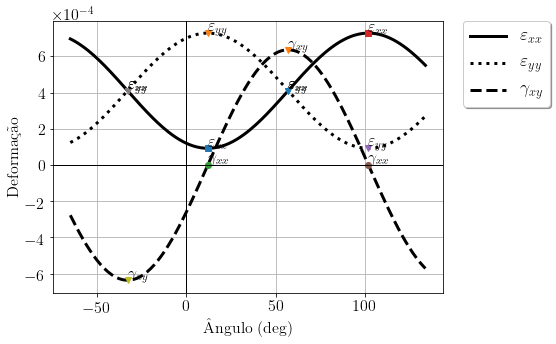

In [32]:
import matplotlib.pyplot as plt
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16
rc('text', usetex=True)

def epsx1(eXX,eYY,gXY,t): return eXX*np.cos(t)**2 + eYY*np.sin(t)**2 + gXY*np.sin(t)*np.cos(t)
def epsy1(eXX,eYY,gXY,t): return eXX*np.sin(t)**2 + eYY*np.cos(t)**2 - gXY*np.sin(t)*np.cos(t)
def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)

#epsXX = matDef[0,0]
#epsYY = matDef[1,1]
#gamXY = matDef[0,1]

tang = np.arange(-65,135,1) # unidades: Deg
# extensões normais
extXang = epsx1(epsXX,epsYY,gamXY,np.deg2rad(tang))
extYang = epsy1(epsXX,epsYY,gamXY,np.deg2rad(tang))
# distorção angular
distang = gammax1y1(epsXX,epsYY,gamXY,np.deg2rad(tang))

print('Extensões principais: -------------------------------------------')
ePIa = epsx1(epsXX,epsYY,gamXY,aPI)
ePIIa = epsy1(epsXX,epsYY,gamXY,aPI)
dPIa = gammax1y1(epsXX,epsYY,gamXY,aPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPI)))
print('            Extensão I =','{:.5e}'.format(ePIa))
print('           Extensão II =','{:.5e}'.format(ePIIa))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIa)))

ePIb = epsx1(epsXX,epsYY,gamXY,aPII)
ePIIb = epsy1(epsXX,epsYY,gamXY,aPII)
dPIb = gammax1y1(epsXX,epsYY,gamXY,aPII)
print('\nÂngulo principal (Deg) =','{:.2f}'.format(np.rad2deg(aPII)))
print('            Extensão I =','{:.5e}'.format(ePIb))
print('           Extensão II =','{:.5e}'.format(ePIIb))
print('   Distorção de corte  =','{:.1f}'.format(np.abs(dPIb)))

def gammax1y1(eXX,eYY,gXY,t): return -(eXX - eYY)*np.sin(2*t) + gXY*np.cos(2*t)
def angShearMax(exx,eyy,gxy): return np.arctan( -(exx-eyy)/gxy )

corteAngP1 = angShearMax(epsXX,epsYY,gamXY)
corteAngP2 = corteAngP1 + np.pi
corteAngPI = corteAngP1/2
corteAngPII = corteAngP2/2

print('\nDistorções principais: -------------------------------------------')
epsx1ShearPa = epsx1(epsXX,epsYY,gamXY,corteAngPI)
epsy1ShearPa = epsy1(epsXX,epsYY,gamXY,corteAngPI)
cortePa = gammax1y1(epsXX,epsYY,gamXY,corteAngPI)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPI)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPa))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPa)))
print('   Distorção principal =','{:.5e}'.format(cortePa))

epsx1ShearPb = epsx1(epsXX,epsYY,gamXY,corteAngPII)
epsy1ShearPb = epsy1(epsXX,epsYY,gamXY,corteAngPII)
cortePb = gammax1y1(epsXX,epsYY,gamXY,corteAngPII)
print('Ângulo principal (Deg) =','{:.2f}'.format(np.rad2deg(corteAngPII)))
print('            Extensão I =','{:.5e}'.format(epsx1ShearPb))
print('           Extensão II =','{:.5e}'.format(np.abs(epsy1ShearPb)))
print('   Distorção principal =','{:.5e}'.format(cortePb))

# use LaTeX fonts in the plot
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(tang, extXang, 'k-', label=r'$\varepsilon_{xx}$', linewidth=3)
ax.plot(tang, extYang, 'k:', label=r'$\varepsilon_{yy}$', linewidth=3)
ax.plot(tang, distang, 'k--', label=r'$\gamma_{xy}$', linewidth=3)

ax.plot(np.rad2deg(aPI), ePIa, 's')
ax.text(np.rad2deg(aPI), ePIa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPI), ePIIa, 'v')
ax.text(np.rad2deg(aPI), ePIIa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPI), dPIa, 'o')
ax.text(np.rad2deg(aPI), dPIa,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(aPII), ePIb, 's')
ax.text(np.rad2deg(aPII), ePIb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(aPII), ePIIb, 'v')
ax.text(np.rad2deg(aPII), ePIIb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(aPII), dPIb, 'o')
ax.text(np.rad2deg(aPII), dPIb,r'$\gamma_{xx}$')

ax.plot(np.rad2deg(corteAngPI), epsx1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsx1ShearPa,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPI), epsy1ShearPa, 'v')
ax.text(np.rad2deg(corteAngPI), epsy1ShearPa,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPI), cortePa, 'v')
ax.text(np.rad2deg(corteAngPI), cortePa,r'$\gamma_{xy}$')

ax.plot(np.rad2deg(corteAngPII), epsx1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsx1ShearPb,r'$\varepsilon_{xx}$')
ax.plot(np.rad2deg(corteAngPII), epsy1ShearPb, 'v')
ax.text(np.rad2deg(corteAngPII), epsy1ShearPb,r'$\varepsilon_{yy}$')
ax.plot(np.rad2deg(corteAngPII), cortePb, 'v')
ax.text(np.rad2deg(corteAngPII), cortePb,r'$\gamma_{xy}$')

plt.ticklabel_format(axis='y',style='sci',scilimits=(1,4))
ax.set(xlabel='Ângulo (deg)', ylabel='Deformação')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

